# Notebook 1: Introduction to Quantum Machine Learning

## Classifying Iris Flowers with Angle Encoding

**CQTS Summer Training Program 2026 | High School Track**

In this beginner lesson, we will build a small **hybrid quantum machine learning model** with PennyLane.

The model will learn to classify an Iris flower as:

- **Setosa**
- **Versicolor**
- **Virginica**

Each flower has four measurements:

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

We will use one qubit for each measurement, so the quantum circuit will use **four qubits**.


## 1. Install the required libraries

The next cell installs the libraries only when they are missing.

This works in Google Colab and most Jupyter environments.

In [1]:
import importlib.util
import subprocess
import sys

packages = {
    "pennylane": "pennylane",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
}

for module_name, package_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", package_name]
        )

print("The required libraries are ready.")

The required libraries are ready.


## 2. Import the libraries

We use:

- **PennyLane** to build the quantum circuit
- **scikit-learn** to load the dataset and train the final classifier
- **Matplotlib** to draw graphs
- **Pandas** to display tables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
)

SEED = 7
np.random.seed(SEED)

print("PennyLane version:", qml.__version__)

PennyLane version: 0.42.1


## 3. Load the Iris dataset

The Iris dataset contains **150 flowers**.

There are **50 flowers from each species** and four measurements for every flower.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

flower_table = pd.DataFrame(X, columns=iris.feature_names)
flower_table["species"] = [iris.target_names[label] for label in y]

print("Number of flowers:", len(flower_table))
print("Flower species:", list(iris.target_names))

flower_table.head()

Number of flowers: 150
Flower species: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### How many flowers are in each class?

In [3]:
flower_table["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 4. Look at the flower data

A scatter plot helps us see that the flower species form different groups.

We will plot petal length against petal width.

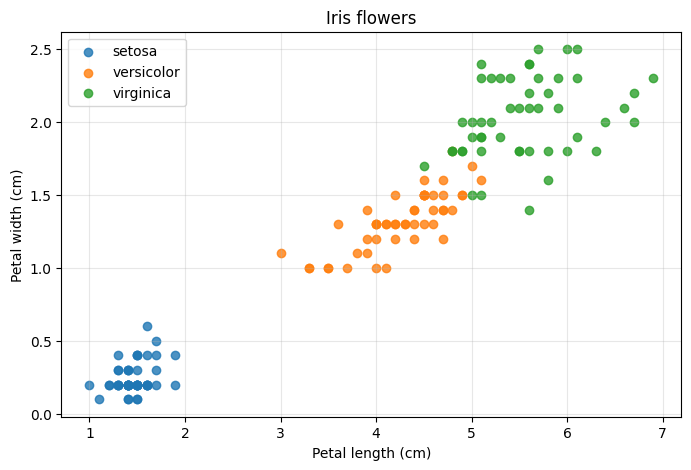

In [4]:
plt.figure(figsize=(8, 5))

for species_number, species_name in enumerate(iris.target_names):
    rows = y == species_number
    plt.scatter(
        X[rows, 2],
        X[rows, 3],
        label=species_name,
        alpha=0.8,
    )

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris flowers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Split the data

We use:

- **80%** of the flowers for training
- **20%** of the flowers for testing

The test set contains flowers the model does not see during training.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Training flowers:", len(X_train))
print("Test flowers:", len(X_test))

Training flowers: 120
Test flowers: 30


## 6. Convert measurements into quantum angles

Quantum rotation gates use angles.

We scale every flower measurement to a value between $-\frac{\pi}{2} \quad \text{and} \quad \frac{\pi}{2}$

The scaled numbers will control the rotations of the qubits.

In [6]:
angle_scaler = MinMaxScaler(
    feature_range=(-np.pi / 2, np.pi / 2)
)

X_train_angles = angle_scaler.fit_transform(X_train)
X_test_angles = angle_scaler.transform(X_test)

print("First flower before scaling:")
print(np.round(X_train[0], 2))

print("\nFirst flower after scaling:")
print(np.round(X_train_angles[0], 2))

First flower before scaling:
[7.4 2.8 6.1 1.9]

First flower after scaling:
[ 1.13 -0.71  1.14  0.79]


## 7. Build the quantum circuit

We use four qubits:

- Qubit 0 receives sepal length
- Qubit 1 receives sepal width
- Qubit 2 receives petal length
- Qubit 3 receives petal width

For each qubit, an `RY` gate rotates the qubit using one flower measurement.

We then measure each qubit in two ways:

- The Pauli-Z measurement
- The Pauli-X measurement

Four qubits with two measurements each give us **eight quantum features**.

In [7]:
number_of_qubits = 4

device = qml.device(
    "default.qubit",
    wires=number_of_qubits,
)


@qml.qnode(device)
def quantum_feature_circuit(flower_angles):
    # Put the four flower measurements into four qubits
    qml.AngleEmbedding(
        flower_angles,
        wires=range(number_of_qubits),
        rotation="Y",
    )

    # Measure every qubit in the Z and X directions
    z_measurements = [
        qml.expval(qml.PauliZ(qubit))
        for qubit in range(number_of_qubits)
    ]

    x_measurements = [
        qml.expval(qml.PauliX(qubit))
        for qubit in range(number_of_qubits)
    ]

    return z_measurements + x_measurements

## 8. Draw the quantum circuit

Each horizontal line is one qubit.

The `RY` boxes are rotation gates. The numbers inside them come from one flower.

In [8]:
example_flower = X_train_angles[0]

print(qml.draw(
    quantum_feature_circuit,
    level="device",
)(example_flower))

0: ──RY(1.13)──┤  <Z>  <X>
1: ──RY(-0.71)─┤  <Z>  <X>
2: ──RY(1.14)──┤  <Z>  <X>
3: ──RY(0.79)──┤  <Z>  <X>


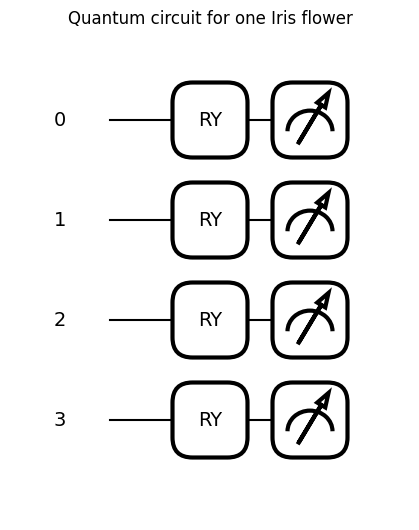

In [9]:
fig, ax = qml.draw_mpl(
    quantum_feature_circuit,
    level="device",
)(example_flower)

fig.suptitle("Quantum circuit for one Iris flower", y=1.02)
plt.show()

## 9. Test the circuit with one flower

The circuit returns eight numbers.

These numbers are the quantum features that describe the flower.

In [10]:
one_flower_quantum_features = quantum_feature_circuit(
    example_flower
)

print(
    np.round(
        np.array(one_flower_quantum_features),
        3,
    )
)

[ 0.423  0.756  0.413  0.707  0.906 -0.655  0.911  0.707]


## 10. Convert all flowers into quantum features

We run every flower through the same circuit.

The circuit turns four input measurements into eight quantum features.

In [12]:
def create_quantum_features(angle_data):
    quantum_rows = []

    for flower_angles in angle_data:
        features = quantum_feature_circuit(flower_angles)
        quantum_rows.append(np.array(features, dtype=float))

    return np.array(quantum_rows)


Q_train = create_quantum_features(X_train_angles)
Q_test = create_quantum_features(X_test_angles)

print("Training quantum feature shape:", Q_train.shape)
print("Test quantum feature shape:", Q_test.shape)

Training quantum feature shape: (120, 8)
Test quantum feature shape: (30, 8)


### View the first five quantum feature rows

In [13]:
quantum_feature_names = [
    "Z0", "Z1", "Z2", "Z3",
    "X0", "X1", "X2", "X3",
]

pd.DataFrame(
    Q_train[:5],
    columns=quantum_feature_names,
).round(3)

,Z0,Z1,Z2,Z3,X0,X1,X2,X3
0,0.423,0.756,0.413,0.707,0.906,-0.655,0.911,0.707
1,0.643,0.841,0.263,0.383,-0.766,0.541,-0.965,-0.924
2,0.174,0.756,0.106,0.383,0.985,0.655,0.994,0.924
3,0.866,0.959,0.638,0.131,0.500,-0.282,0.770,0.991
4,0.985,1.000,0.461,-0.000,0.174,-0.000,0.887,1.000


## 11. Train the hybrid QML model

Our beginner model has two parts:

```text
Flower measurements
        |
        v
Four-qubit feature circuit
        |
        v
Eight quantum features
        |
        v
Classical output layer
        |
        v
Predicted flower species
```

The quantum circuit creates the features.

The classical output layer learns how to connect those features to the three flower species.

In [14]:
model = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.05,
    penalty="l2",
    alpha=0.0001,
    random_state=SEED,
)

classes = np.array([0, 1, 2])
epochs = 100

training_loss = []
training_accuracy = []
test_accuracy = []

random_generator = np.random.default_rng(SEED)

for epoch in range(epochs):
    # Shuffle the training flowers
    order = random_generator.permutation(len(Q_train))

    # Learn from one pass through the training set
    model.partial_fit(
        Q_train[order],
        y_train[order],
        classes=classes,
    )

    # Calculate the loss
    train_probabilities = model.predict_proba(Q_train)
    current_loss = log_loss(
        y_train,
        train_probabilities,
        labels=classes,
    )

    # Calculate training and test accuracy
    train_predictions = model.predict(Q_train)
    test_predictions = model.predict(Q_test)

    current_train_accuracy = accuracy_score(
        y_train,
        train_predictions,
    )

    current_test_accuracy = accuracy_score(
        y_test,
        test_predictions,
    )

    training_loss.append(current_loss)
    training_accuracy.append(current_train_accuracy)
    test_accuracy.append(current_test_accuracy)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Loss: {current_loss:.3f} | "
            f"Train accuracy: {current_train_accuracy:.3f} | "
            f"Test accuracy: {current_test_accuracy:.3f}"
        )

Epoch  20 | Loss: 0.160 | Train accuracy: 0.950 | Test accuracy: 1.000
Epoch  40 | Loss: 0.120 | Train accuracy: 0.958 | Test accuracy: 1.000
Epoch  60 | Loss: 0.101 | Train accuracy: 0.967 | Test accuracy: 1.000
Epoch  80 | Loss: 0.094 | Train accuracy: 0.967 | Test accuracy: 1.000
Epoch 100 | Loss: 0.089 | Train accuracy: 0.967 | Test accuracy: 1.000


## 12. Plot the training loss

Loss measures how far the model's predictions are from the correct answers.

A lower loss is better.

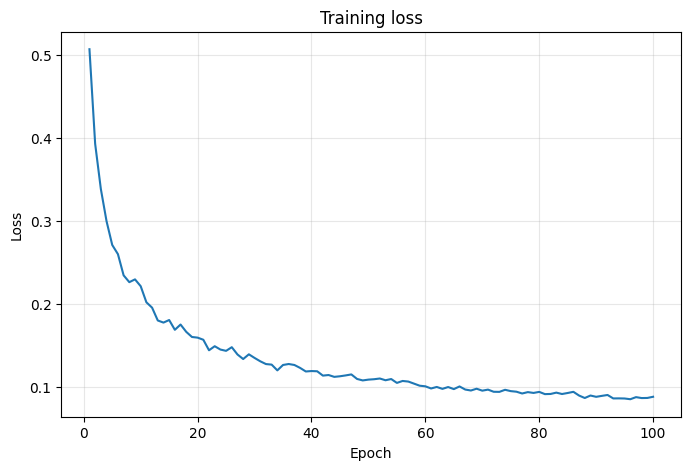

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), training_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.show()

## 13. Plot training and test accuracy

Accuracy is the fraction of predictions that are correct.

A value of `1.0` means 100% accuracy.

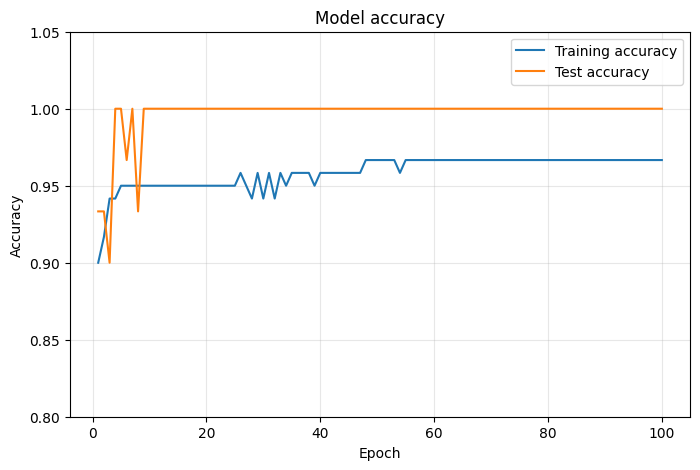

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, epochs + 1),
    training_accuracy,
    label="Training accuracy",
)
plt.plot(
    range(1, epochs + 1),
    test_accuracy,
    label="Test accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model accuracy")
plt.ylim(0.8, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Final accuracy

In [18]:
final_train_predictions = model.predict(Q_train)
final_test_predictions = model.predict(Q_test)

final_train_accuracy = accuracy_score(
    y_train,
    final_train_predictions,
)

final_test_accuracy = accuracy_score(
    y_test,
    final_test_predictions,
)

print(
    f"Final training accuracy: "
    f"{final_train_accuracy * 100:.1f}%"
)

print(
    f"Final test accuracy: "
    f"{final_test_accuracy * 100:.1f}%"
)

Final training accuracy: 96.7%
Final test accuracy: 100.0%


## 15. Classification report

The report contains:

- **Precision:** When the model predicts a species, how often is it correct?
- **Recall:** How many flowers from that species did the model find?
- **F1-score:** A score that combines precision and recall
- **Support:** The number of test flowers in each species

In [19]:
report_text = classification_report(
    y_test,
    final_test_predictions,
    target_names=iris.target_names,
    digits=3,
)

print(report_text)

              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      1.000     1.000     1.000        10
   virginica      1.000     1.000     1.000        10

    accuracy                          1.000        30
   macro avg      1.000     1.000     1.000        30
weighted avg      1.000     1.000     1.000        30



In [20]:
report_dictionary = classification_report(
    y_test,
    final_test_predictions,
    target_names=iris.target_names,
    output_dict=True,
)

report_table = pd.DataFrame(
    report_dictionary
).transpose()

report_table.round(3)

,precision,recall,f1-score,support
setosa,1.0,1.0,1.0,10.0
versicolor,1.0,1.0,1.0,10.0
virginica,1.0,1.0,1.0,10.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,30.0
weighted avg,1.0,1.0,1.0,30.0


## 16. Confusion matrix

A confusion matrix shows the correct and incorrect predictions.

The diagonal boxes contain correct predictions.

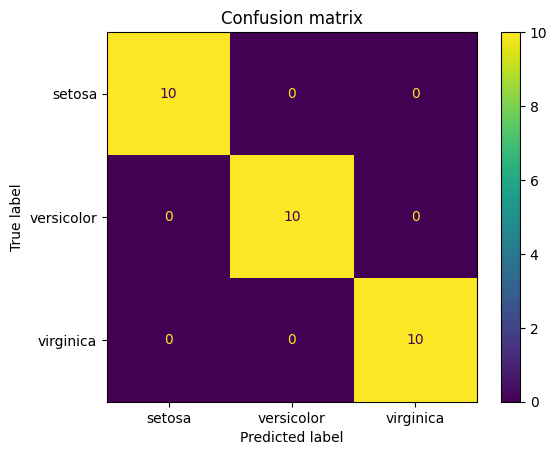

In [21]:
matrix = confusion_matrix(
    y_test,
    final_test_predictions,
)

display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=iris.target_names,
)

display.plot()
plt.title("Confusion matrix")
plt.show()

## 17. Look at individual predictions

In [22]:
prediction_table = pd.DataFrame({
    "True species": [
        iris.target_names[label]
        for label in y_test
    ],
    "Predicted species": [
        iris.target_names[label]
        for label in final_test_predictions
    ],
})

prediction_table["Correct"] = (
    prediction_table["True species"]
    == prediction_table["Predicted species"]
)

prediction_table.head(15)

,True species,Predicted species,Correct
0,virginica,virginica,True
1,setosa,setosa,True
2,setosa,setosa,True
3,versicolor,versicolor,True
4,virginica,virginica,True
5,versicolor,versicolor,True
6,virginica,virginica,True
7,setosa,setosa,True
8,virginica,virginica,True
9,virginica,virginica,True


## 18. Try your own flower

Change the four measurements below and run the cell again.

The order is:

```text
sepal length, sepal width, petal length, petal width
```

In [23]:
my_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

my_flower_angles = angle_scaler.transform(my_flower)
my_quantum_features = create_quantum_features(
    my_flower_angles
)

my_prediction = model.predict(
    my_quantum_features
)[0]

print(
    "Predicted species:",
    iris.target_names[my_prediction],
)

Predicted species: setosa


## 19. Student activities

### Activity 1

Change the number of training epochs from `100` to `20`.

- What happens to the loss?
- What happens to the accuracy?

### Activity 2

Change `eta0=0.05` to `eta0=0.005`.

- Does the model learn faster or slower?

### Activity 3

Remove the four Pauli-X measurements from the circuit.

- How many quantum features remain?
- Does the test accuracy change?

### Activity 4

Change the measurements in `my_flower`.

- Which measurements produce Setosa?
- Which measurements produce Virginica?

## Official references

- [PennyLane QNodes](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html)
- [PennyLane AngleEmbedding](https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html)
- [scikit-learn Iris dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
- [scikit-learn classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)